# Credit Modeling Demo



Reference document that does two things:
* Demonstrates how to work with various packages related to model evaluation, interpretability, and debiasing
* Provides brief explanations/refreshers on key concepts relevant to the demo

<br>

Structure of the document:
* Creating synthetic data
* Fitting some models
  * Logistic regression
  * XGBoost
  * Explainable Boosting Machines (EBM)
* Evaluating each model
* Exploring feature importances for each model
* Developing debiased XGBoost models using Fairlearn

<br>

Concepts addressed throughout:
* Model types
  * Intuition behind XGBoost and EBMs
* Model evaluation
  * Refresher on confusion matrix and common metrics (FPR, TPR, precision, etc.)
  * Refresher on AUC
* Feature importances
  * How to interpret logistic regression coefficients and assess feature importances
  * How to use SHAP to assess feature importances for non-interpretable models
  * How to interpret EBM outputs
  * Relationship between log-odds and probability
* Debiasing
  * Intuition behind Fairlearn's Reductions approach
  * Accuracy-fairness tradeoffs

<br>

This document is also available as a Google Colab notebook [here](https://colab.research.google.com/drive/1CIt0QeXzO0YyinuNs_5QappI-r9lpXxo?usp=sharing).

## Creating synthetic data

In [ ]:
## Installing any missing packages
#!pip install interpret
#!pip install fairlearn

## Loading necessary packages
import numpy as np
import pandas as pd
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
from sklearn import preprocessing
import xgboost
import matplotlib.pyplot as plt
from interpret import glassbox
from interpret import show
import statsmodels.api as sm
import shap
from fairlearn import metrics as flm
from fairlearn import reductions

In [ ]:
## Setting a seed
np.random.seed(123)

## Setting up some probability distributions I'll use
p_balanced = [0.025, 0.025, 0.1, 0.15, 0.2, 0.2, 0.15, 0.1, 0.025, 0.025]
p_skew_left = [0.025, 0.1, 0.15, 0.2, 0.2, 0.15, 0.1, 0.025, 0.025, 0.025]
p_skew_right = [0.025, 0.025, 0.025, 0.1, 0.15, 0.2, 0.2, 0.15, 0.1, 0.025]

## Creating some synthetic data for the y = 1 (bads) class
credit_score_1 = np.random.choice(np.arange(400, 900, 50), p = p_skew_left, size = 100)
income_1 = np.random.choice(np.arange(25000, 275000, 25000), p = p_skew_left, size = 100)
delinquencies_1 = np.random.choice(np.arange(0, 10), p = p_skew_right, size = 100)
debt_1 = np.random.choice(np.arange(25000, 275000, 25000), p = p_skew_right, size = 100)
bankruptcy_1 = np.random.choice(np.arange(0, 2), p = [0.7, 0.3], size = 100)
sensitive_1 = np.random.choice(np.arange(0, 2), p = [0.7, 0.3], size = 100)

## Creating some synthetic data for the y = 0 (goods) class
credit_score_0 = np.random.choice(np.arange(400, 900, 50), p = p_skew_right, size = 900)
income_0 = np.random.choice(np.arange(25000, 275000, 25000), p = p_skew_right, size = 900)
delinquencies_0 = np.random.choice(np.arange(0, 10), p = p_skew_left, size = 900)
debt_0 = np.random.choice(np.arange(25000, 275000, 25000), p = p_skew_left, size = 900)
bankruptcy_0 = np.random.choice(np.arange(0, 2), p = [0.9, 0.1], size = 900)
sensitive_0 = np.random.choice(np.arange(0, 2), p = [0.9, 0.1], size = 900)

## Creating df for the y = 1 (bads) class
df_1 = pd.DataFrame({'credit_score': credit_score_1,
                     'income': income_1,
                     'delinquencies': delinquencies_1,
                     'debt': debt_1,
                     'bankruptcy': bankruptcy_1,
                     'y_bad': 1,
                     'sensitive': sensitive_1})

## Creating df for the y = 0 (goods) class
df_0 = pd.DataFrame({'credit_score': credit_score_0,
                     'income': income_0,
                     'delinquencies': delinquencies_0,
                     'debt': debt_0,
                     'bankruptcy': bankruptcy_0,
                     'y_bad': 0,
                     'sensitive': sensitive_0})

## Concatenating into one df
df = pd.concat([df_0, df_1], ignore_index = True)

## Save off x and y vars
x = df.drop(['y_bad', 'sensitive'], axis = 1)
y = df['y_bad']

## Train test splits
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size = 0.2, random_state = 123)

## Getting matching train test splits for sensitive var
sens_train = df['sensitive'].loc[x_train.index]
sens_test = df['sensitive'].loc[x_test.index]

In [ ]:
## Check out the size of our objects
print('df:', df.shape)
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('sens_train:', sens_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)
print('sens_test:', sens_test.shape)

df: (1000, 7)
x_train: (800, 5)
y_train: (800,)
sens_train: (800,)
x_test: (200, 5)
y_test: (200,)
sens_test: (200,)


In [ ]:
## Check out the data
df.head(5)

,credit_score,income,delinquencies,debt,bankruptcy,y_bad,sensitive
0,700,150000,4,100000,0,0,0
1,700,100000,9,150000,0,0,0
2,800,225000,3,75000,0,0,0
3,800,175000,2,100000,0,0,0
4,650,150000,2,150000,0,0,0


## Fitting some models

### Logistic Regression

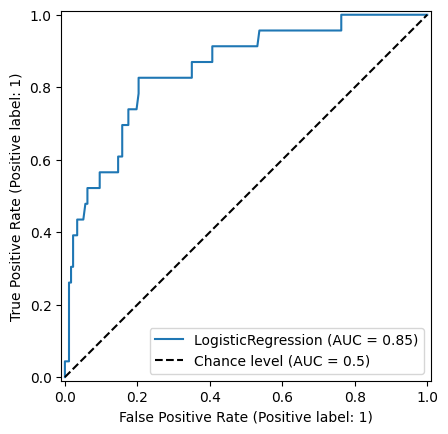

In [ ]:
## Creating the model object
log_reg = linear_model.LogisticRegression(max_iter = 500)

## Fitting the model
log_reg.fit(x_train, y_train)

## Check out the ROC curve
metrics.RocCurveDisplay.from_estimator(log_reg, x_test, y_test, plot_chance_level = True)
plt.show()

### XGBoost


XGBoost is a popular implementation of gradient boosted decision trees. I'm including some very brief notes on gradient boosted trees and resources for further reading below.

* Ensemble of "weak learner" decision trees, often a couple hundred to a couple thousand, each with something like 1-8 layers
* These weak learners are combined together to form a strong learner
* After each round, the next weak learner aims to predict the remaining error that the strong learner is currently producing
* Each of the terminal nodes on each weak learner is associated with a log-odds value
* Once the model has been fitted, any observation that is run through the model will receive a log-odds value from each weak learner, which are then summed together to get their final log-odds value. This can then be converted to a predicted probability.

Resources:
* [XGBoost docs](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)
* [Gradient Boosted Decision Trees - Google ML docs](https://developers.google.com/machine-learning/decision-forests/intro-to-gbdt)

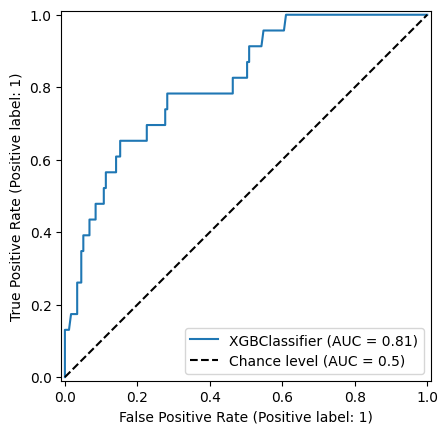

In [ ]:
## Creating the model object - starting without any hyperparam tuning
xgb = xgboost.XGBClassifier(objective = 'binary:logistic')

## Fitting the model
xgb.fit(x_train, y_train)

## Check out the ROC curve
metrics.RocCurveDisplay.from_estimator(xgb, x_test, y_test, plot_chance_level = True)
plt.show()

We can see that the XGBoost model performs worse than the logistic regression model out of the box. Let's see if we can improve its performance with some light hyperparameter tuning.

In [ ]:
## Setting up some params
params = {'max_depth': list(range(1,11)),
          'n_estimators': [25, 50, 100, 150, 200]}

## Doing a grid search with cross-validation
xgb_grid = model_selection.GridSearchCV(xgb, param_grid = params, scoring = 'roc_auc', cv = 5, verbose = 1)
xgb_grid.fit(x_train, y_train);

Fitting 5 folds for each of 50 candidates, totalling 250 fits


ROC Curve for XGBoost with best params: {'max_depth': 2, 'n_estimators': 50}

 Cross-validated AUC: 0.8916 



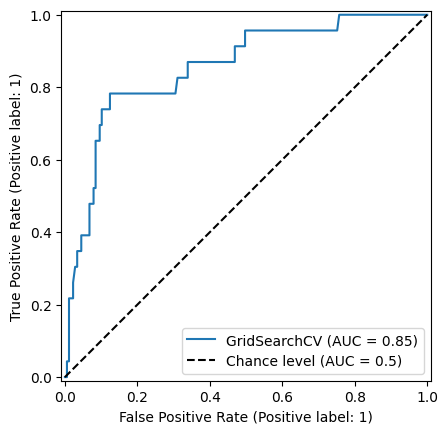

In [ ]:
## Plotting the ROC curve
print('ROC Curve for XGBoost with best params:', xgb_grid.best_params_)
print('\n', 'Cross-validated AUC:', round(xgb_grid.best_score_, 4), '\n')
metrics.RocCurveDisplay.from_estimator(xgb_grid, x_test, y_test, plot_chance_level = True)
plt.show()

We can see that the XGBoost model now performs on par with the logistic regression model on the test data. We can also see that the model has stronger performance on the cross-validated training data (0.89), as compared with the test data (0.85).

In [ ]:
## Creating the model object - now with hyperparams from above
xgb = xgboost.XGBClassifier(objective = 'binary:logistic', max_depth = 2, n_estimators = 50)

## Fitting the model
xgb.fit(x_train, y_train);

### Explainable Boosting Machines (EBM)

EBMs are an interesting alternative to gradient boosted trees, which tend to trade off a little bit of accuracy in exchange for being much more interpretable. They do so by restricting the model to only having trees of either a) single variables, or b) a select number of two-way interactions. I provide more detail on the intuition behind EBMs in the feature importances section below, and you can also find more information about them in the [EBM docs](https://interpret.ml/docs/ebm.html).

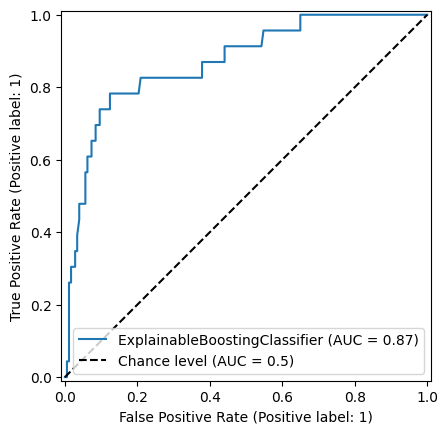

In [ ]:
## Creating the model object
ebm = glassbox.ExplainableBoostingClassifier()

## Fitting the model
ebm.fit(x_train, y_train)

## Check out the ROC curve
metrics.RocCurveDisplay.from_estimator(ebm, x_test, y_test, plot_chance_level = True)
plt.show()

We can see that the EBM model performs a bit better than the logistic regression and XGBoost models. This likely indicates there's more hyperparameter tuning we could be doing on the XGBoost model; EBMs generally trade off a little predictive power in service of interpretability, so we'd expect a well-calibrated XGBoost model to at least slightly out-perform the EBM.

## Evaluating each of the models



**Refresher on confusion matrix and common metrics**

First, let's do a quick refresher on the confusion matrix and associated metrics in scikit-learn. Scikit-learn structures the confusion matrix differently than many other places, so I'm including a graphic of how it's structured below for reference. Here are how some of the key metrics are defined and calculated.

* True Positive Rate (TPR): TP / (TP + FN)
  * Percentage of actual positives that are correctly classified as such
  * In the credit context, TPs would be defaulters who are correctly denied loans
  * AKA recall, sensitivity
* False Positive Rate (FPR): FP / (FP + TN)
  * Percentage of actual negatives that are incorrectly classified as positives
  * In the credit context, FPs would be non-defaulters who are incorrectly denied loans
* True Negative Rate (TNR): TN / (FP + TN)
  * Percentage of actual negatives that are correctly classified as such
  * In the credit context, TNs would be non-defaulters who are correctly given loans
  * AKA specificity
* False Negative Rate (FNR): FN / (TP + FN)
  * Percentage of actual positives that are incorrectly identified as negatives
  * In the credit context, FNs would be defaulters who are incorrectly given loans
* Precision: TP / (TP + FP)
  * Percentage of predicted positives that are actually positives
  * Precision/recall tradeoff: if you wanted to improve recall, you could simply classify every observation as positive; but doing so would severely damage precision.
* Default Rate: FN / (TN + FN)
  * Percentage of predicted negatives that are actually positives
* Accuracy: (TN + TP) / (TN + FP + FN + TP)
  * Percentage of correct predictions




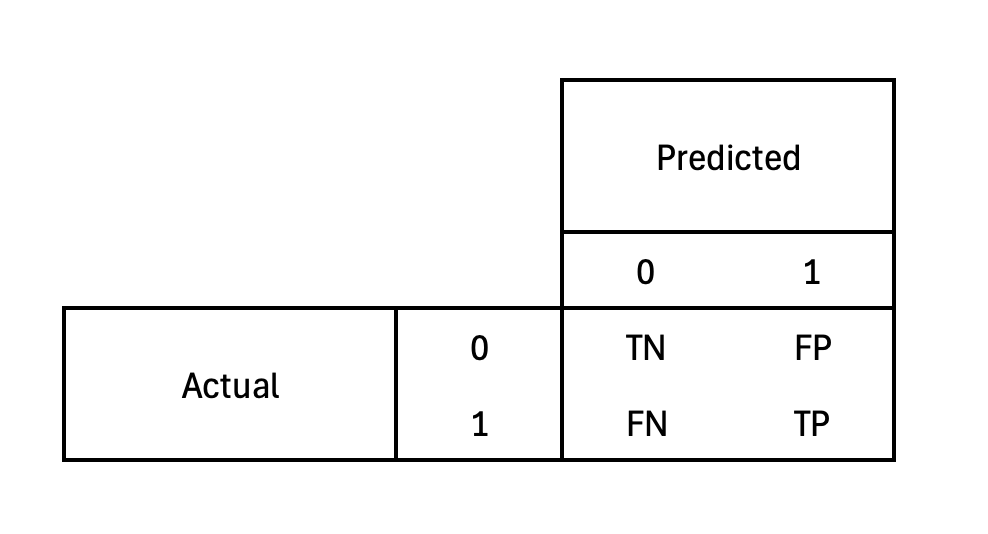

**Refresher on AUC**

Let's also do a quick refresher on AUC. Area under the curve (AUC) is a threshold-agnostic measure of accuracy, reflecting how well the model rank orders negative and positive class observations. More specifically, it "represents the probability that the model, if given a randomly chosen positive and negative example, will rank the positive higher than the negative."

We can also look at it graphically. In the graph below, the x-axis is the FPR and the y-axis is the TPR. The ROC curve represents the FPR and TPR values at various decision thresholds. AUC represents the area underneath that curve and all the way to the bottom and right of the sqaure. The dotted line represents a model choosing totally at random. Gini represents the area between the ROC curve and the dotted line.

Let's walk through an example in the credit context. A model that had a super lenient cutoff of say 0.95 would not identify too many true positives, but it also wouldn't have many false positives - virtually everyone with predicted probabilities > 0.95 are bads. So that would put us at the bottom/left of the ROC curve. Say we instead chose a cutoff of 0.75. We'd now be identifying more true positives, but at the expense of likely a few false positives. So we'd be starting to move up and to the right a bit on the curve. Continue with this logic until you're looking at extremely stringent cutoffs, say 1%, in which you're identifying virtually every true positive, but also now capturing tons of false positives. That puts you in the top/right of the curve.

Perfect model = AUC of 1; model guessing at random = AUC of 0.5.

Resources:
* [Classification: ROC and AUC - Google ML docs](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)

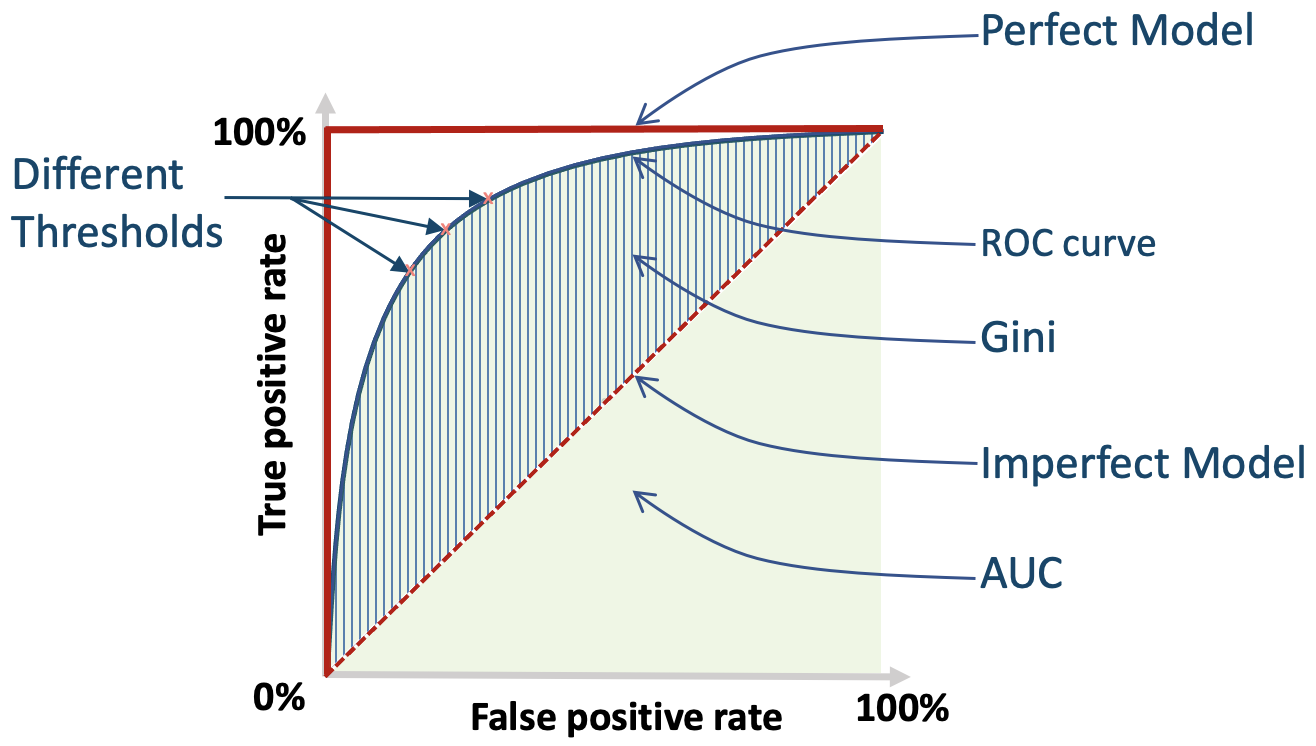

In [ ]:
## Getting predicted probs for each model type
log_reg_preds = log_reg.predict_proba(x_test)[:,1]
xgb_preds = xgb.predict_proba(x_test)[:,1]
ebm_preds = ebm.predict_proba(x_test)[:,1]

## Putting them all into a df together
y_test_df = pd.DataFrame({'y_bad': y_test,
                          'sensitive': sens_test,
                          'log_reg_pred_prob': log_reg_preds,
                          'xgb_pred_prob': xgb_preds,
                          'ebm_pred_prob': ebm_preds})

## Making decisions for each model type, using a threshold of 0.1
y_test_df['log_reg_decision'] = 0
y_test_df.loc[(y_test_df['log_reg_pred_prob'] > 0.1), 'log_reg_decision'] = 1

y_test_df['xgb_decision'] = 0
y_test_df.loc[(y_test_df['xgb_pred_prob'] > 0.1), 'xgb_decision'] = 1

y_test_df['ebm_decision'] = 0
y_test_df.loc[(y_test_df['ebm_pred_prob'] > 0.1), 'ebm_decision'] = 1

### Logistic Regression

In [ ]:
## AUC (same as before; threshold-agnostic)
print("AUC =", round(metrics.roc_auc_score(y_test_df['y_bad'], y_test_df['log_reg_pred_prob']), 4), '\n')

## Confusion matrix
log_reg_cm = metrics.confusion_matrix(y_test_df['y_bad'], y_test_df['log_reg_decision'])
print('Confusion Matrix:', '\n')
print(log_reg_cm, '\n')

## Classification accuracy
print('Classification Accuracy =', round(metrics.accuracy_score(y_test_df['y_bad'], y_test_df['log_reg_decision']), 4))

## TPR
print('TPR =', round(metrics.recall_score(y_test_df['y_bad'], y_test_df['log_reg_decision']), 4))

## FPR
print('FPR =', round(log_reg_cm[0,1] / (log_reg_cm[0,0] + log_reg_cm[0,1]), 4))

AUC = 0.8495 

Confusion Matrix: 

[[141  36]
 [  5  18]] 

Classification Accuracy = 0.795
TPR = 0.7826
FPR = 0.2034


### XGBoost

In [ ]:
## AUC (same as before; threshold-agnostic)
print("AUC =", round(metrics.roc_auc_score(y_test_df['y_bad'], y_test_df['xgb_pred_prob']), 4), '\n')

## Confusion matrix
xgb_cm = metrics.confusion_matrix(y_test_df['y_bad'], y_test_df['xgb_decision'])
print('Confusion Matrix:', '\n')
print(xgb_cm, '\n')

## Classification accuracy
print('Classification Accuracy =', round(metrics.accuracy_score(y_test_df['y_bad'], y_test_df['xgb_decision']), 4))

## TPR
print('TPR =', round(metrics.recall_score(y_test_df['y_bad'], y_test_df['xgb_decision']), 4))

## FPR
print('FPR =', round(xgb_cm[0,1] / (xgb_cm[0,0] + xgb_cm[0,1]), 4))

AUC = 0.8549 

Confusion Matrix: 

[[148  29]
 [  5  18]] 

Classification Accuracy = 0.83
TPR = 0.7826
FPR = 0.1638


### Explainable Boosting Machines (EBM)

In [ ]:
## AUC (same as before; threshold-agnostic)
print("AUC =", round(metrics.roc_auc_score(y_test_df['y_bad'], y_test_df['ebm_pred_prob']), 4), '\n')

## Confusion matrix
ebm_cm = metrics.confusion_matrix(y_test_df['y_bad'], y_test_df['ebm_decision'])
print('Confusion Matrix:', '\n')
print(ebm_cm, '\n')

## Classification accuracy
print('Classification Accuracy =', round(metrics.accuracy_score(y_test_df['y_bad'], y_test_df['ebm_decision']), 4))

## TPR
print('TPR =', round(metrics.recall_score(y_test_df['y_bad'], y_test_df['ebm_decision']), 4))

## FPR
print('FPR =', round(ebm_cm[0,1] / (ebm_cm[0,0] + ebm_cm[0,1]), 4))

AUC = 0.8699 

Confusion Matrix: 

[[150  27]
 [  5  18]] 

Classification Accuracy = 0.84
TPR = 0.7826
FPR = 0.1525


We can see that the XGBoost model performs better than the logistic regression model across a range of metrics: XGBoost has slightly higher AUC, higher classification accuracy, and lower FPR (TPR is equal).

We can also see the the EBM model performs better than the XGBoost model across a range of metrics: EBM has higher AUC, higher classification accuracy, and lower FPR (TPR is equal).

## Exploring feature importances for each model type


### Logistic Regression

In [ ]:
## Check out the coefficients
pd.DataFrame({'variable': log_reg.feature_names_in_, 'coefficient': log_reg.coef_[0]})

,variable,coefficient
0,credit_score,-0.007073
1,income,-0.000014
2,delinquencies,0.324458
3,debt,0.000016
4,bankruptcy,1.281000


Assuming all of these variables are statistically significant, the interpretations for each would be:

* credit_score: A 1 point increase in credit score is associated with a 0.007 decrease in the log-odds of defaulting on the loan, on average, with all else equal.
* income: A 1 dollar increase in income is associated with a 0.00001 decrease in the log-odds of defaulting on the loan, on average, with all else equal.
* delinquencies: 1 additional delinquency is associated with a 0.32 increase in the log-odds of defaulting on the loan, on average, with all else equal.
* debt: A 1 dollar increase in debt is associated with a 0.00002 increase in the log-odds of defaulting on the loan, on average, with all else equal.
* bankruptcy: Having experienced bankruptcy is associated with a 1.28 increase in the log-odds of defaulting on the loan, on average, with all else equal.

The first four variables were all simulated based on the same probability distribution, so the coefficients should net out to be roughly the same once we adjust for the magnitudes of the unit increases between each of the steps (i.e., credit score was in increments of 50, income and debt were in increments of 25,000, and delinquency was in increments of 1).



In [ ]:
## Putting them in comparable units
print('credit_score coefficient x 50 =', round(log_reg.coef_[0][0] * 50, 4))
print('income coefficient x 25,000 =', round(log_reg.coef_[0][1] * 25000, 4))
print('delinquencies coefficient x 1 =', round(log_reg.coef_[0][2] * 1, 4))
print('debt coefficient x 25,000 =', round(log_reg.coef_[0][3] * 25000, 4))

credit_score coefficient x 50 = -0.3536
income coefficient x 25,000 = -0.3496
delinquencies coefficient x 1 = 0.3245
debt coefficient x 25,000 = 0.4122


To be more precise, and to be able to compare the 5th variable directly - which was simulated with a different probability distribution - we should re-run the model with the variables all standardized. That will give us coefficients in standard deviation terms rather than raw unit terms.

In [ ]:
## Standardize the x vars
scaler = preprocessing.StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

## Creating a fresh model object
log_reg_std = linear_model.LogisticRegression(max_iter = 500)

## Fitting the model with standardized x vars
log_reg_std.fit(x_train_std, y_train);

In [ ]:
## Check out the coefficients on the model with standardized x vars
pd.DataFrame({'variable': log_reg.feature_names_in_, 'coefficient': log_reg_std.coef_[0]})

,variable,coefficient
0,credit_score,-0.756249
1,income,-0.717557
2,delinquencies,0.624308
3,debt,0.799175
4,bankruptcy,0.447799


Assuming all of these variables are statistically significant, the interpretations for each would be:

* credit_score: A 1 standard deviation increase in credit score is associated with a 0.76 decrease in the log-odds of defaulting on the loan, on average, with all else equal.
* income: A 1 standard deviation increase in income is associated with a 0.72 decrease in the log-odds of defaulting on the loan, on average, with all else equal.
* delinquencies: A 1 standard deviation increase in delinquencies is associated with a 0.62 increase in the log-odds of defaulting on the loan, on average, with all else equal.
* debt: A 1 standard deviation increase in debt is associated with a 0.80 increase in the log-odds of defaulting on the loan, on average, with all else equal.
* bankruptcy: A 1 standard deviation increase in bankruptcy is associated with a 0.45 increase in the log-odds of defaulting on the loan, on average, with all else equal.

Now we can see that bankruptcy actually has a smaller effect on likelihood of default than the other variables, based on the probability distribution we used to simulate it.

As a final step, I'll run the same logistic regression model in the statsmodels package so we can see whether each of the variables are statistically significant.

In [ ]:
## Add constant to x vars
x_train_cons = sm.add_constant(x_train)

## Building the model and fitting the data
log_reg_sm = sm.Logit(y_train, x_train_cons).fit()

## Check out summary
print(log_reg_sm.summary())

Optimization terminated successfully.
         Current function value: 0.219539
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  y_bad   No. Observations:                  800
Model:                          Logit   Df Residuals:                      794
Method:                           MLE   Df Model:                            5
Date:                Fri, 07 Mar 2025   Pseudo R-squ.:                  0.3069
Time:                        04:22:31   Log-Likelihood:                -175.63
converged:                       True   LL-Null:                       -253.41
Covariance Type:            nonrobust   LLR p-value:                 8.738e-32
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5528      0.985      0.561      0.575      -1.379       2.484
credit_score     -0.

We can see that they're all statistically significant at all conventional significance levels.

### XGBoost

To start off, let's take a quick look at one of the trees in the ensemble.

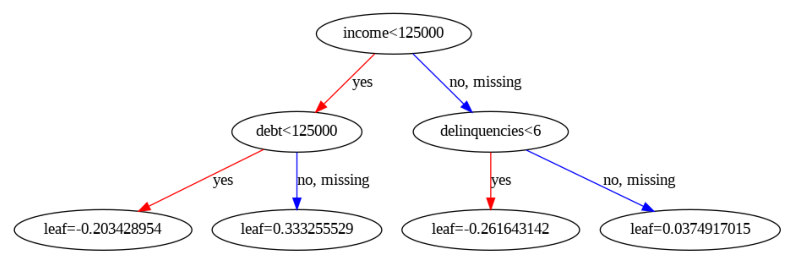

In [ ]:
## Looking at one of the trees
fig, ax = plt.subplots(figsize=(10, 10))
xgboost.plot_tree(xgb, num_trees=1, ax = ax)
plt.show()

This gives us some helpful info, but even with a tree this shallow and a relatively small number of trees in this model (50), it's still going to be very difficult to draw any real conclusions from looking at the trees directly. Instead, we'll turn to SHAP to help us make sense of the feature importances.

As an aside, for reference, the numerical values in the leaf nodes are log-odds values. The final predicted log-odds value for a given observation is just the sum of the log-odds values from the leaf nodes of where that person ends up in each tree.

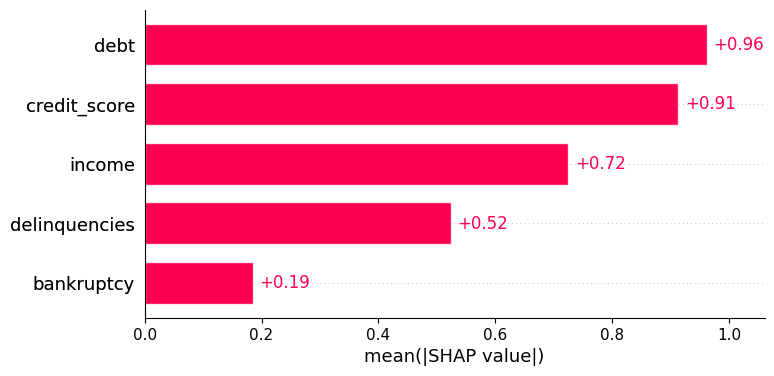

In [ ]:
## Getting SHAP values
explainer = shap.Explainer(xgb, x_test)
shap_values = explainer(x_test)

## Look at overall summary plot bars
shap.plots.bar(shap_values)

Note that these follow the same order as the standardized logistic regression coefficients.

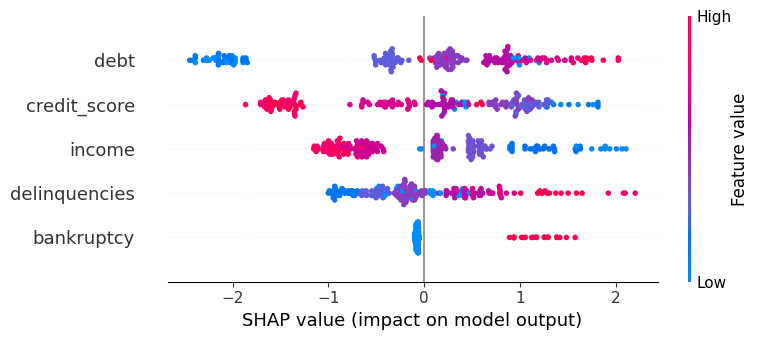

In [ ]:
## Look at overall summary plot beeswarm
shap.summary_plot(shap_values, x_test)

This gives us some similar info, but also shows directionality.

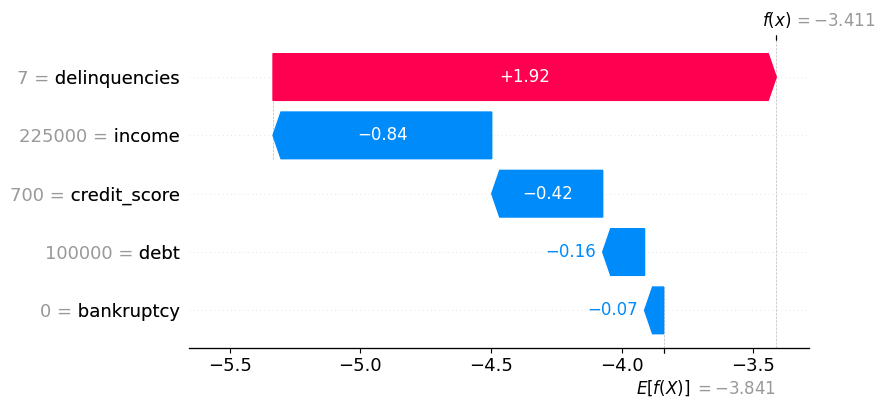

In [ ]:
## Waterfall plot for individual obs
shap.plots.waterfall(shap_values[0])

The values shown here are all log-odds values. So we can interpret this as:

* The intercept value being -3.841 log-odds
* Moving from bottom to top, each of the variables is increasingly having a larger effect on log-odds
* Bankruptcy, with a value of 0 for this person, slightly reduces log-odds by 0.07 - meaning they're less likely to default
* Debt, with a value of 100,000, slightly reduces log-odds by 0.16 - meaning they're less likely to default
* Credit score, with a value of 700, modestly reduces log-odds by 0.42 - meaning they're less likely to default
* Income, with a value of 225,000, reduces log-odds by 0.84 - meaning they're less likely to default
* Delinquencies, with a value of 7, increases log-odds by 1.92 - meaning they're more likely to default

The final predicted value, summing up the intercept and each of the variable log-odds impacts, is -3.411. Below, we convert that to probability, and show that it matches the predicted probability for this observation.

Note: you have to be a bit careful with indexing here; we're looking at index 0 of `shap_values`, which corresponds with the first observation in `x_test` and `y_test_df`, but that observation has an index of 131 in those dfs (because it was randomly selected when doing our train/test splits).

In [ ]:
## Converting log-odds to prob
log_odds_val = -3.411
round(1 / (1 + np.exp(-log_odds_val)), 4)

0.032

In [ ]:
## Looking at first row of df
y_test_df[:1]

,y_bad,sensitive,log_reg_pred_prob,xgb_pred_prob,ebm_pred_prob,log_reg_decision,xgb_decision,ebm_decision
131,0,0,0.016806,0.031965,0.00683,0,0,0


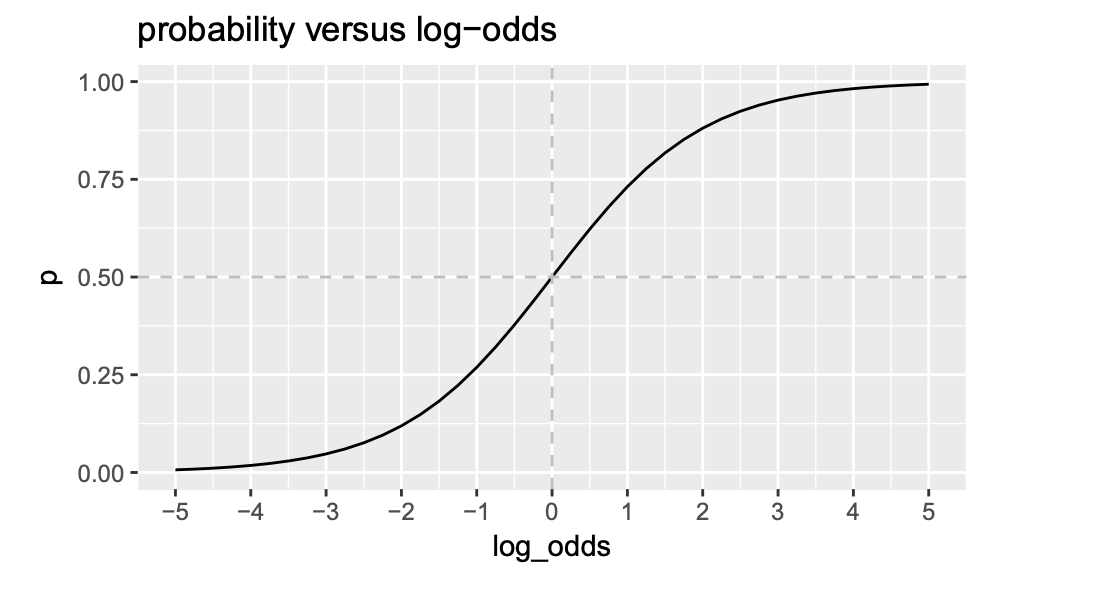

As a refresher, if probability = 0.2:
* odds = p / (1-p) = 0.2 / 0.8 = 0.25
* log-odds = ln(0.25) = -1.3863

[Probability, odds, log-odds conversion calculator](http://vassarstats.net/tabs_odds.html)

### Explainable Boosting Machines (EBM)

In [ ]:
## Look at global explanations
#show(ebm.explain_global())

Note: I've commented out the above code and instead included a few screenshots below because the outputs don't render well when I go to export the notebook. But it produces an interactive cell that lets you look at the global feature importances or drill down on the relationship between a given variable and log-odds.

The global importances show the same order as the standardized logistic regression coefficients and the XGBoost SHAP feature importances.

The graph for credit score shows how log-odds values decrease as credit score increases.



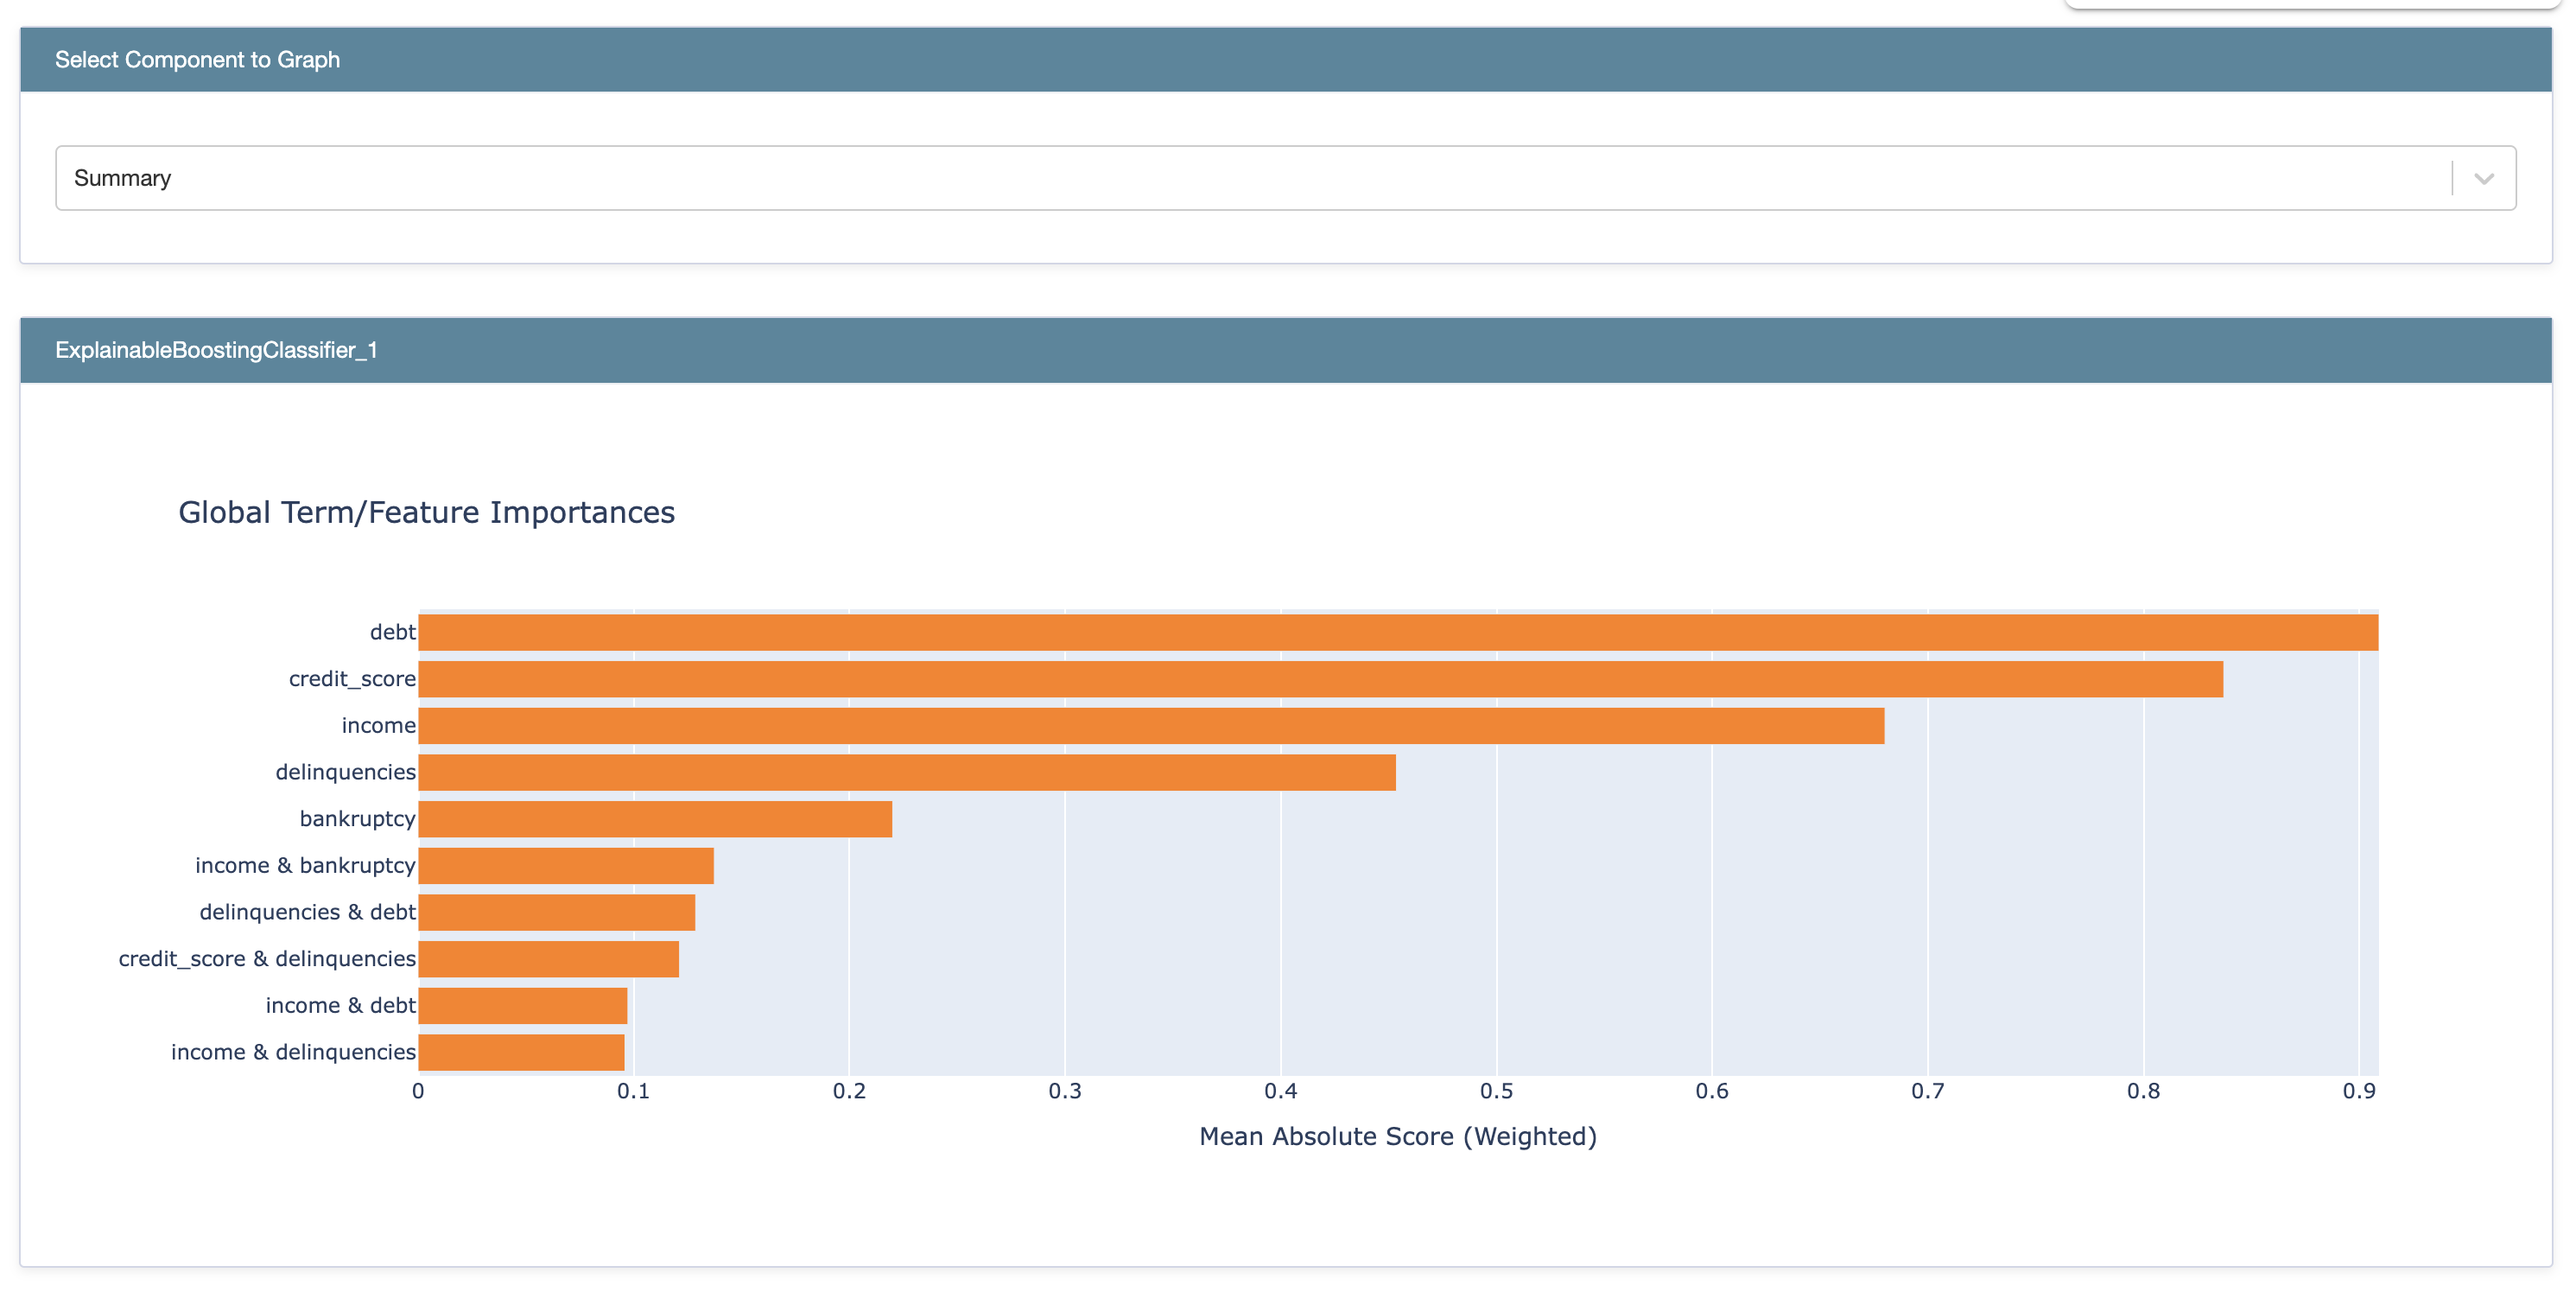

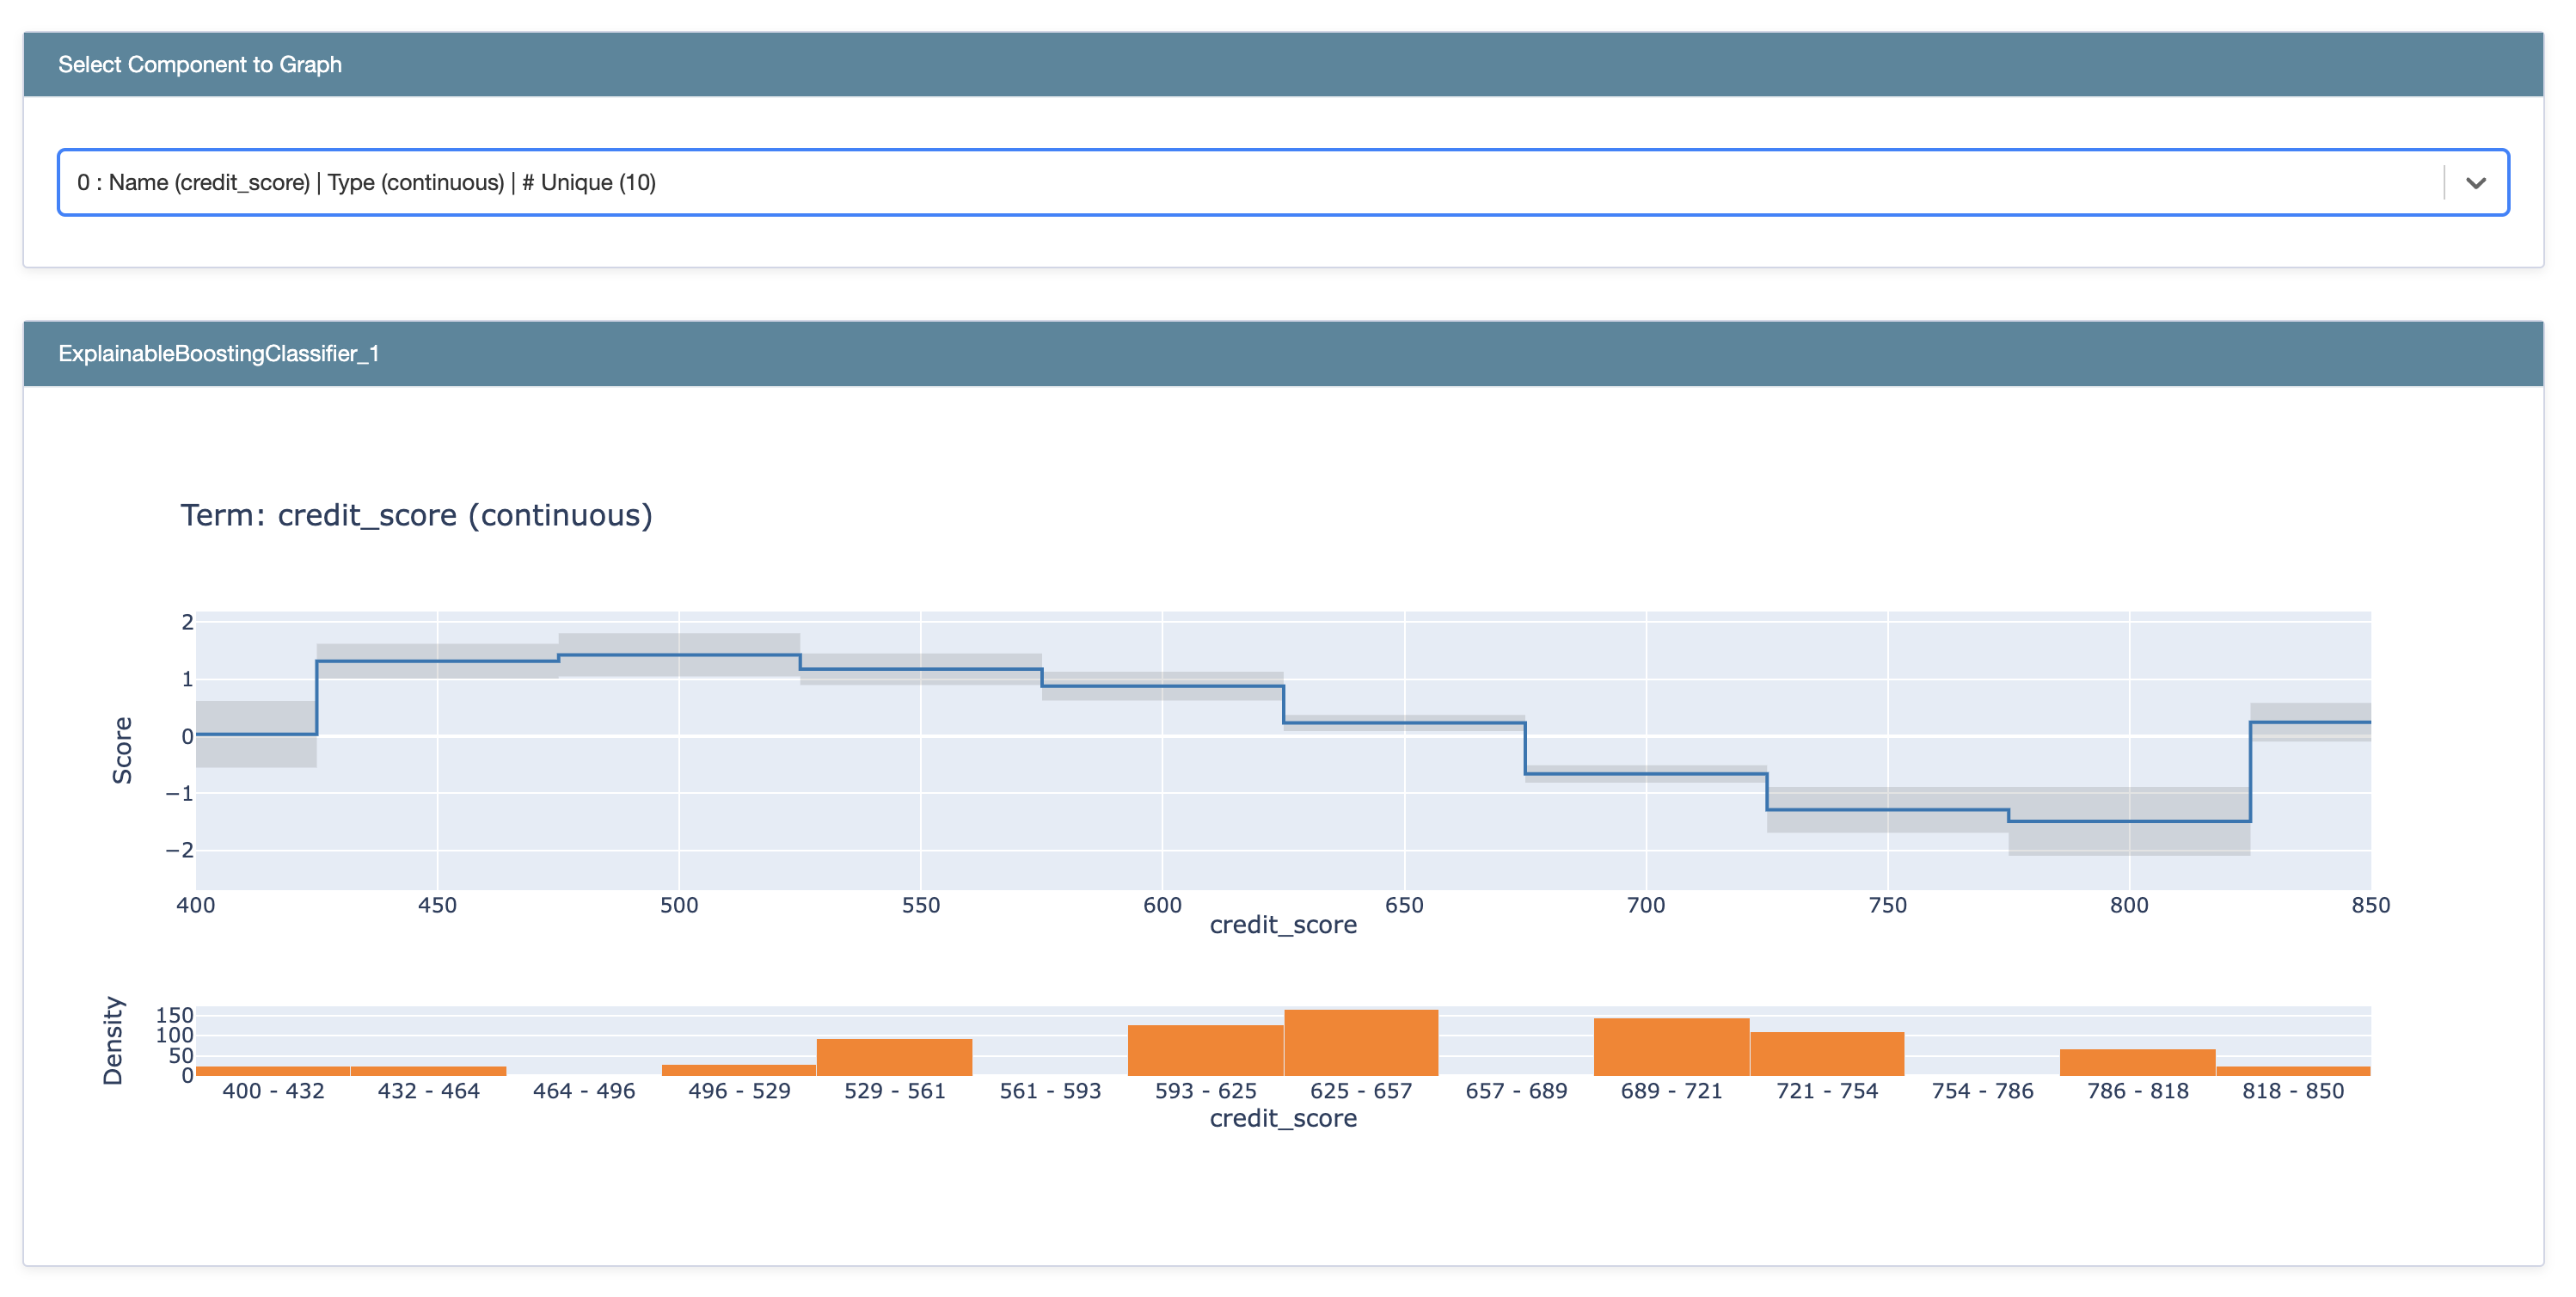

It's worth talking about how the graphs like the credit score one above are generated. The video on the EBM docs [here](https://interpret.ml/docs/ebm.html) does a good job of explaining it, and I'll attempt to summarize it in rough terms here too:

* The model consists of terms, which are either individual variables or the interaction of two variables. Every variable you provide is included as a term, and the model additionally selects a few of the possible two-way interactions to include.
  * The package uses some computationally efficient method for selecting the interaction terms that are most helpful for prediction
* Let's put those interaction terms aside for a moment and just focus on the individual variables. Each variable ends up with a graph like the one above, which shows the log-odds value associated with each value of the variable.
* These graphs are the result of thousands of rounds of iteration for each variable, where each round is a shallow tree making a split or two on that variable alone, and ending up with a few leaves with log-odds scores associated with them (default max_leaves is 3, but you can adjust this).
* If you run a given observation through all of these trees for a given variable, you'll get a cumulative log-odds value, which is just the sum of all the individual tree log-odds values.
* If you do that for all observations, then you're left with a mapping of each possible value of the variable to a log-odds score. At this point, you can throw away the trees themselves and just represent it with a graph like the one above.
* At run time, the model just does a lookup of each term against these functions, and the observation's final log-odds prediction is just the sum of the log-odds values from all of these term functions.
* Thus, we can see how any given variable affects the final score for each observation (local feature importances), and we can see how variables cumulatively affect log-odds scores across all observations (global feature importances).



In [ ]:
## Look at local explanations (just first obs)
#show(ebm.explain_local(x_test[:1], y_test[:1]), 0)

Looking at the same observation as the XGBoost SHAP local explanation above, we see the same exact patterns play out here.

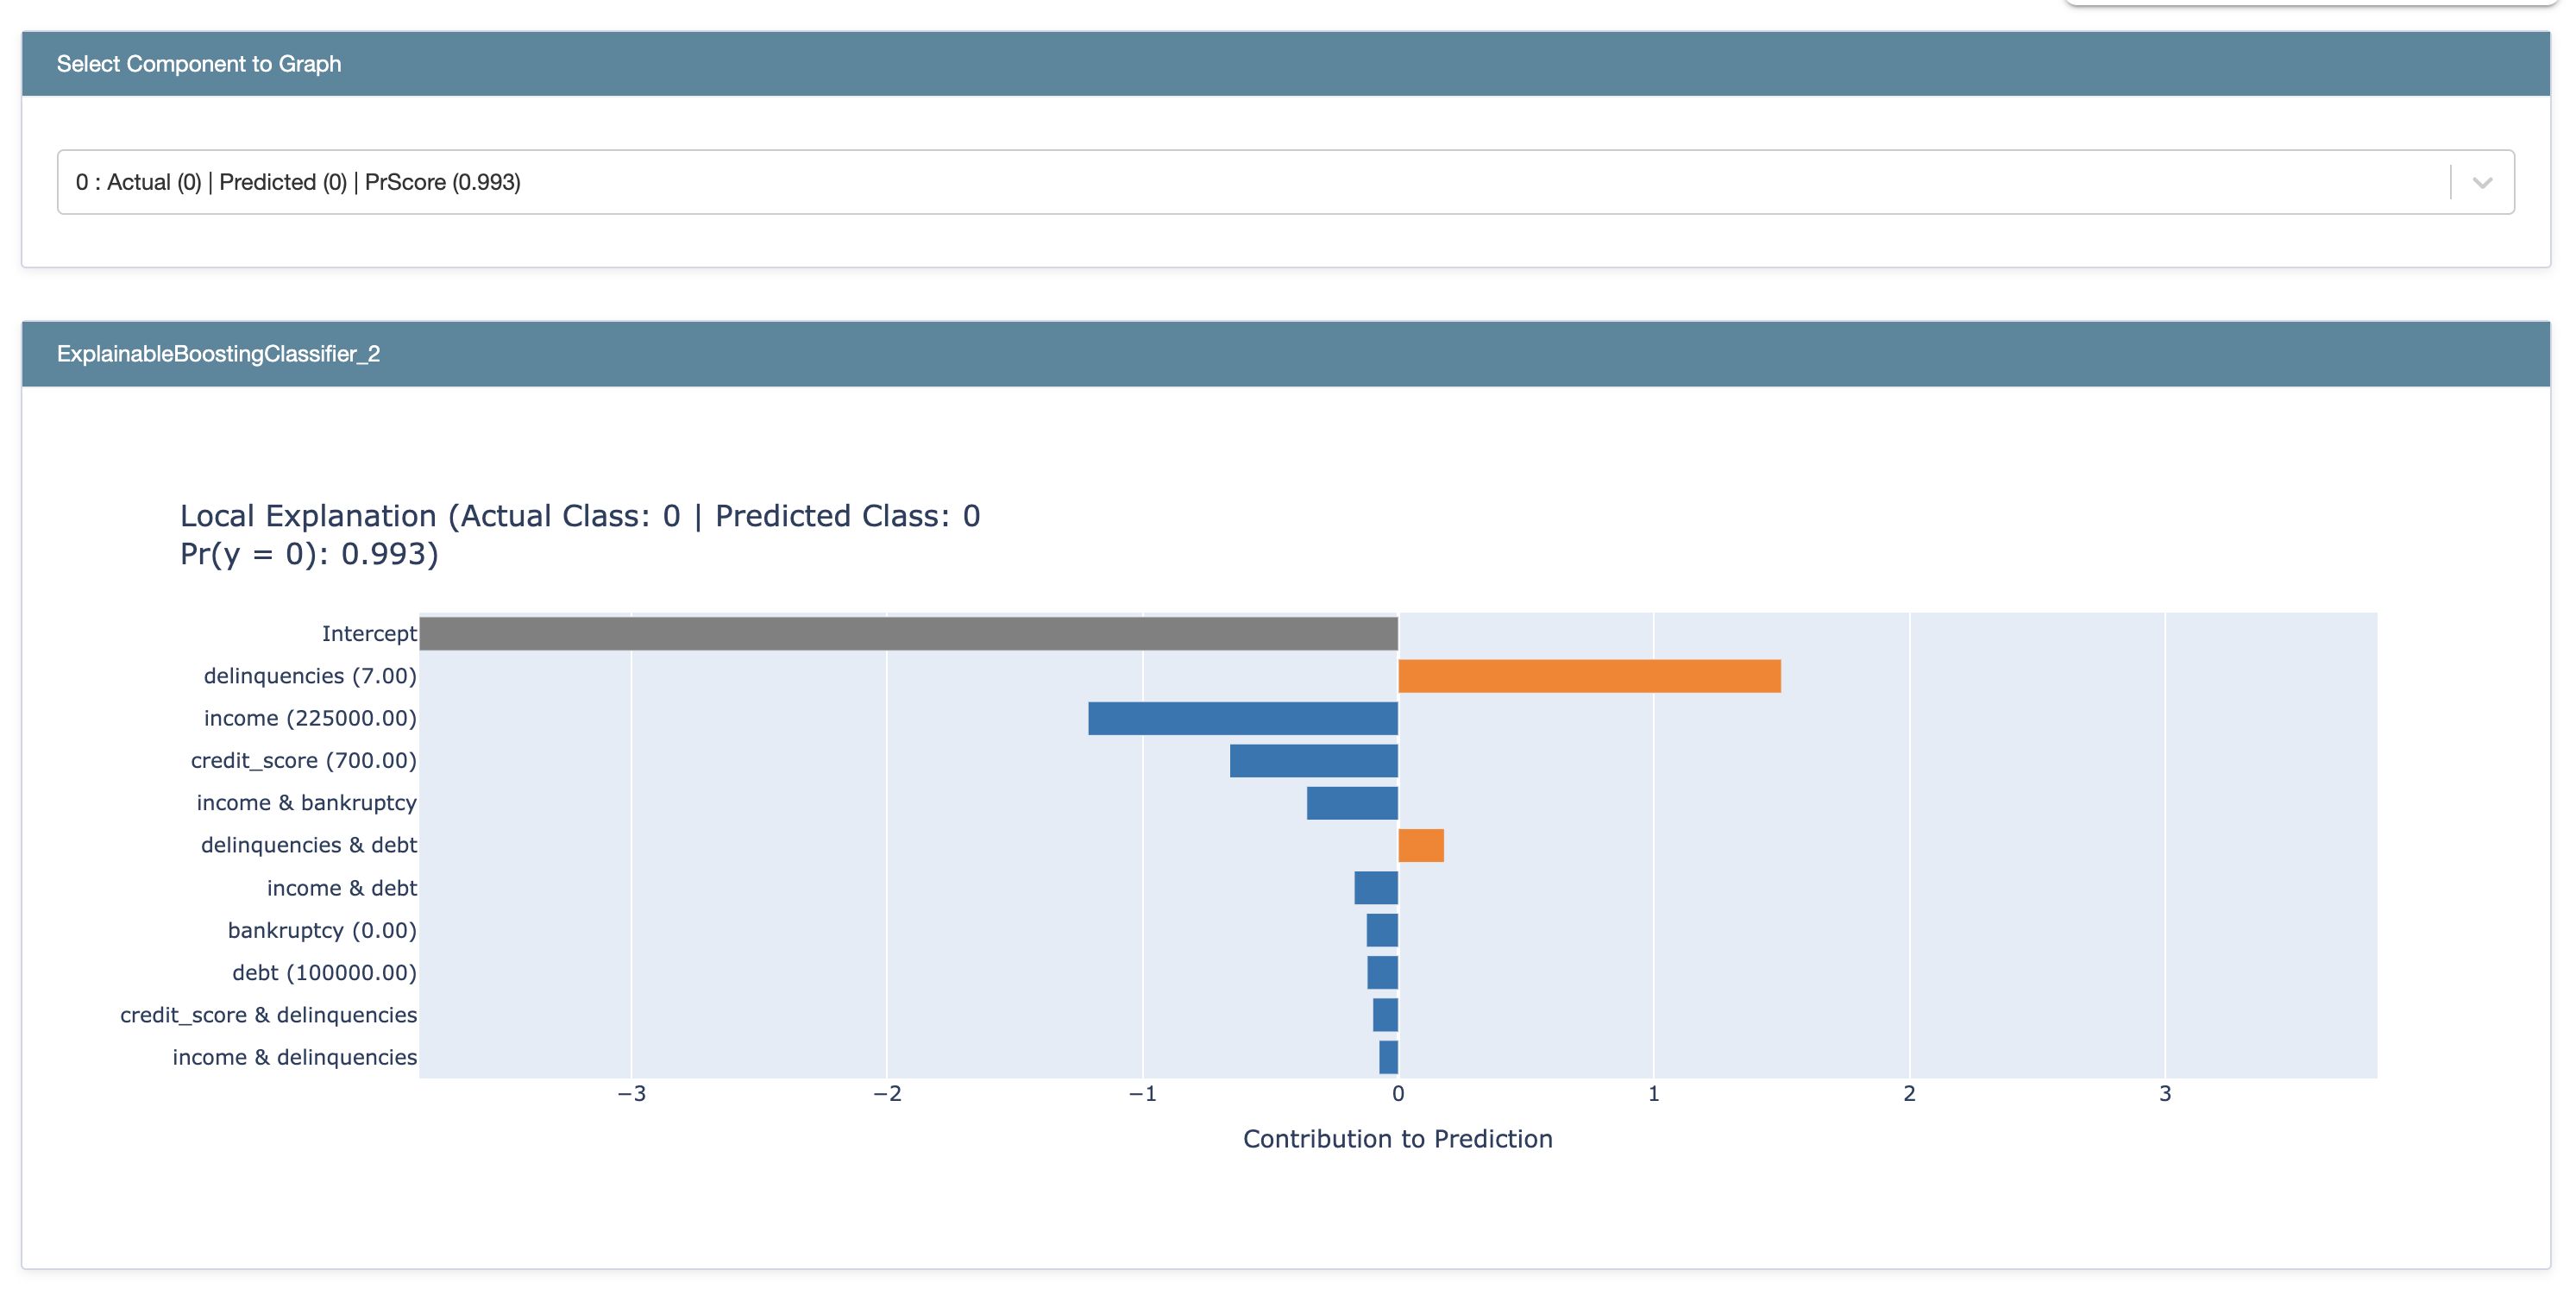

## Developing debiased models using Fairlearn

We'll first look at some metrics by race, and then get into the debiasing. I provide some high-level info on the debiasing approach when it gets introduced further down in this section.

For simplicity, we'll just go through the debiasing exercise with the XGBoost model, but the process would be the same for logistic regression and EBM.

We'll say `sensitive == 1` are Black applicants and `sensitive == 0` are White applicants.

In [ ]:
## Overall section
print('Total Population:', '\n')

## AUC (same as before; threshold-agnostic)
print("AUC =", round(metrics.roc_auc_score(y_test_df['y_bad'], y_test_df['xgb_pred_prob']), 4))

## Confusion matrix
xgb_cm = metrics.confusion_matrix(y_test_df['y_bad'], y_test_df['xgb_decision'])
print('Confusion Matrix:')
print(xgb_cm)

## Classification accuracy
print('Classification Accuracy =', round(metrics.accuracy_score(y_test_df['y_bad'], y_test_df['xgb_decision']), 4))

## TPR
print('TPR =', round(metrics.recall_score(y_test_df['y_bad'], y_test_df['xgb_decision']), 4))

## FPR
print('FPR =', round(xgb_cm[0,1] / (xgb_cm[0,0] + xgb_cm[0,1]), 4), '\n', '\n')


## White applicants
print('White Applicants:', '\n')

## AUC (same as before; threshold-agnostic)
print("AUC =", round(metrics.roc_auc_score(y_test_df[(y_test_df['sensitive'] == 0)]['y_bad'],
                                           y_test_df[(y_test_df['sensitive'] == 0)]['xgb_pred_prob']), 4))

## Confusion matrix
xgb_cm_sens0 = metrics.confusion_matrix(y_test_df[(y_test_df['sensitive'] == 0)]['y_bad'],
                                        y_test_df[(y_test_df['sensitive'] == 0)]['xgb_decision'])
print('Confusion Matrix:')
print(xgb_cm_sens0)

## Classification accuracy
print('Classification Accuracy =', round(metrics.accuracy_score(y_test_df[(y_test_df['sensitive'] == 0)]['y_bad'],
                                                                y_test_df[(y_test_df['sensitive'] == 0)]['xgb_decision']), 4))

## TPR
print('TPR =', round(metrics.recall_score(y_test_df[(y_test_df['sensitive'] == 0)]['y_bad'],
                                          y_test_df[(y_test_df['sensitive'] == 0)]['xgb_decision']), 4))

## FPR
print('FPR =', round(xgb_cm_sens0[0,1] / (xgb_cm_sens0[0,0] + xgb_cm_sens0[0,1]), 4), '\n', '\n')


## Black applicants
print('Black Applicants:', '\n')

## AUC (same as before; threshold-agnostic)
print("AUC =", round(metrics.roc_auc_score(y_test_df[(y_test_df['sensitive'] == 1)]['y_bad'],
                                           y_test_df[(y_test_df['sensitive'] == 1)]['xgb_pred_prob']), 4))

## Confusion matrix
xgb_cm_sens1 = metrics.confusion_matrix(y_test_df[(y_test_df['sensitive'] == 1)]['y_bad'],
                                        y_test_df[(y_test_df['sensitive'] == 1)]['xgb_decision'])
print('Confusion Matrix:')
print(xgb_cm_sens1)

## Classification accuracy
print('Classification Accuracy =', round(metrics.accuracy_score(y_test_df[(y_test_df['sensitive'] == 1)]['y_bad'],
                                                                y_test_df[(y_test_df['sensitive'] == 1)]['xgb_decision']), 4))

## TPR
print('TPR =', round(metrics.recall_score(y_test_df[(y_test_df['sensitive'] == 1)]['y_bad'],
                                          y_test_df[(y_test_df['sensitive'] == 1)]['xgb_decision']), 4))

## FPR
print('FPR =', round(xgb_cm_sens1[0,1] / (xgb_cm_sens1[0,0] + xgb_cm_sens1[0,1]), 4))

Total Population: 

AUC = 0.8549
Confusion Matrix:
[[148  29]
 [  5  18]]
Classification Accuracy = 0.83
TPR = 0.7826
FPR = 0.1638 
 

White Applicants: 

AUC = 0.8979
Confusion Matrix:
[[134  23]
 [  2  14]]
Classification Accuracy = 0.8555
TPR = 0.875
FPR = 0.1465 
 

Black Applicants: 

AUC = 0.7071
Confusion Matrix:
[[14  6]
 [ 3  4]]
Classification Accuracy = 0.6667
TPR = 0.5714
FPR = 0.3


We can see that the model performs worse for black applicants on every metric - lower AUC, lower classification accuracy, lower TPR, and higher FPR.

We can also get some of this information (and other stuff) with Fairlearn's built in `MetricFrame` function - see below.

In [ ]:
## Construct a function dictionary
my_metrics = {'Accuracy': metrics.accuracy_score,
              'TPR': metrics.recall_score,
              'FPR': flm.false_positive_rate,
              'Selection_Rate': flm.selection_rate,
              'Count': flm.count}

## Construct a MetricFrame
mf = flm.MetricFrame(metrics = my_metrics,
                     y_true = y_test_df['y_bad'],
                     y_pred = y_test_df['xgb_decision'],
                     sensitive_features = y_test_df['sensitive'])

## Checking out the metrics overall, for each group, and the differences
print('Metric Frame Overall:', '\n', mf.overall, '\n')
print('Metric Frame by Group:', '\n', mf.by_group, '\n')
print('Metric Frame Difference:', '\n', mf.difference())

Metric Frame Overall: 
 Accuracy            0.830000
TPR                 0.782609
FPR                 0.163842
Selection_Rate      0.235000
Count             200.000000
dtype: float64 

Metric Frame by Group: 
            Accuracy       TPR       FPR  Selection_Rate  Count
sensitive                                                     
0          0.855491  0.875000  0.146497        0.213873  173.0
1          0.666667  0.571429  0.300000        0.370370   27.0 

Metric Frame Difference: 
 Accuracy            0.188825
TPR                 0.303571
FPR                 0.153503
Selection_Rate      0.156498
Count             146.000000
dtype: float64


Selection rate (denial rate) difference is referred to as "Demographic Parity Difference" in Fairlearn, which we can also calculate directly like below.

In [ ]:
## Calculating demographic parity difference
round(flm.demographic_parity_difference(y_true = y_test_df['y_bad'],
                                        y_pred = y_test_df['xgb_decision'],
                                        sensitive_features = y_test_df['sensitive'],
                                        method = 'between_groups'), 4)

0.1565

A few very high-level notes on Fairlearn:
* I'm working with the `GridSearch` function of the `Reductions` package in Fairlearn.
* The Reductions approach involves setting a fairness constraint, and then trying to solve a constrained optimization problem where you seek to optimize the model's accuracy subject to that fairness constraint.
* Because the approach works with any type of model you feed it, it essentially treats the original model as a black box. Rather than doing something like adding a penalty term to the objective function, it achieves fairness improvements by reweighting and, in some cases, relabeling the training data.
  * For example, it may down-weight sensitive group bads and up-weight sensitive group goods in the training data. So we are using protected class attributes to reweight/relabel the training data, but the model itself does not consider protected class, and protected class information is not available to the model at decision time.
* (Grossly simplfying) The `GridSearch` function attempts to solve these dual objectives naively and doesn't necessarily produce models that fully satisfy the constraint. It just generates a series of Lagrangian multipliers with values spread across a grid of possible values, and each of those multipliers leads to a certain configuration of reweighting/relabeling of the training data; it then trains the model on that reweighted/relabeled data. The output of the grid search is `grid_size` models, which can then be used by the modeler to assess accuracy and fairness on the test data.

<br>

Two things that are worth noting about the Fairlearn algorithm and how we'll interact it with when evaluating the outputs:

* For optimization purposes, the Fairlearn algorithm uses the default decision threshold associated with a given classifier (usually 0.5). There isn't an easy way to change this, so we just have to let it do its thing and then use the probabilities produced by the candidate LDA models to actually evaluate any changes to disparities using the decision threshold of our choice (in this case, 0.1).
* Fairlearn can only work with binary/categorical sensitive variables; it can't handle BISG probabilities, for example. So if you're working with probabilistic sensitive categories, you need to binarize/categorize them for the algorithm's sake, even if you then re-calculate the metrics using the probabilities once the candidate models have been generated. I've used a binary sensitive group in this case for simplicity, but that won't always be preferable.

Further reading:
* [Fairlearn docs user guide](https://fairlearn.org/main/user_guide/index.html)
* ["A Reductions Approach to Fair Classification"](https://proceedings.mlr.press/v80/agarwal18a/agarwal18a.pdf) - the paper the approach is based on

In [ ]:
## Setting a demographic parity constraint
constraints = reductions.DemographicParity(difference_bound = 0.01)

## Setting up a fresh version of the base model
xgb = xgboost.XGBClassifier(objective = 'binary:logistic', max_depth = 2, n_estimators = 50)

## Setting up the mitigated model with the constraint
mitigator = reductions.GridSearch(xgb, constraints, grid_size = 10)

## Fitting the mitigated model
mitigator.fit(x_train, y_train, sensitive_features = sens_train, control_features = None)

In [ ]:
## Create some empty lists for appending to
dem_par_list = []
auc_list = []

## Looping through each of the models from the grid search
for idx, x in enumerate(mitigator.predictors_):

  ## Create temp y_df with y_bad, sensitive, pred prob from the given candidate model, and resulting decision with same 0.1 threshold
  y_test_df_temp = pd.DataFrame({'y_bad': y_test_df['y_bad'],
                                 'sensitive': y_test_df['sensitive'],
                                 'xgb_pred_prob': mitigator.predictors_[idx].predict_proba(x_test)[:,1]
                                 })
  y_test_df_temp['xgb_decision'] = 0
  y_test_df_temp.loc[(y_test_df_temp['xgb_pred_prob'] > 0.1), 'xgb_decision'] = 1
  y_test_df_temp = y_test_df_temp.astype({'xgb_decision': int})

  ## Demographic parity diff between groups
  dem_par_temp = flm.demographic_parity_difference(y_true = y_test_df_temp['y_bad'],
                                                   y_pred = y_test_df_temp['xgb_decision'],
                                                   sensitive_features = y_test_df_temp['sensitive'],
                                                   method = 'between_groups')

  ## AUC score
  auc_temp = metrics.roc_auc_score(y_test_df_temp['y_bad'], y_test_df_temp['xgb_pred_prob'])

  ## Appending results to relevant lists
  dem_par_list.append(dem_par_temp)
  auc_list.append(auc_temp)


## Getting the same two metrics for our original/unmitigated model
dem_par_temp = flm.demographic_parity_difference(y_true = y_test_df['y_bad'],
                                                 y_pred = y_test_df['xgb_decision'],
                                                 sensitive_features = y_test_df['sensitive'],
                                                 method = 'between_groups')

auc_temp = metrics.roc_auc_score(y_test_df['y_bad'], y_test_df['xgb_pred_prob'])

## Appending them to the end of our lists
dem_par_list.append(dem_par_temp)
auc_list.append(auc_temp)

## Putting the lists into a df
tradeoff_df = pd.DataFrame({'demographic_parity_diff': dem_par_list,
                            'auc': auc_list})

## Renaming the original model index value
tradeoff_df = tradeoff_df.rename(index={10: 'Original'})

In [ ]:
## Take a look at our tradeoff df
tradeoff_df

,demographic_parity_diff,auc
0,0.148362,0.845247
1,0.165703,0.849914
2,0.171484,0.847826
3,0.171484,0.849546
4,0.185399,0.851756
5,0.156498,0.854950
6,0.156498,0.858389
7,0.181974,0.863424
8,0.172768,0.855932
9,0.146221,0.855441


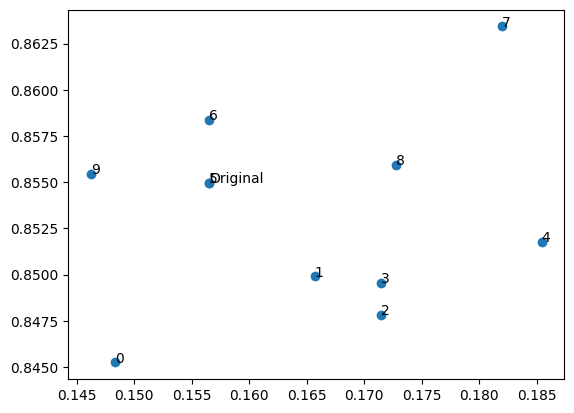

In [ ]:
## Graphing it!
plt.scatter(tradeoff_df['demographic_parity_diff'], tradeoff_df['auc'])

## Putting index labels on it
for idx, row in tradeoff_df.iterrows():
  plt.text(row['demographic_parity_diff'], row['auc'], idx)

These results are a bit funky, either because this is simulated data, or because the XGBoost model was sub-optimized to start, or both. It's not common for Fairlearn to produce models that out-perform the original model in terms of accuracy; usually the original model would be the most accurate, and then the candidate LDA models involve trading off some accuracy for fairness (or bad candidate models that have worse accuracy and worse fairness).

In this case, model candidate 9 seems quite appealing - it is the fairest model produced by the grid search, and actually has slightly better AUC than the original/un-mitigated model.

We'll explore the fuller suite of metrics for model 9 below.

In [ ]:
## Create temp y_df with y_bad, sensitive, pred prob from the given candidate model, and resulting decision with same 0.1 threshold
y_test_df_temp = pd.DataFrame({'y_bad': y_test_df['y_bad'],
                               'sensitive': y_test_df['sensitive'],
                               'xgb_pred_prob': mitigator.predictors_[9].predict_proba(x_test)[:,1]
                                })
y_test_df_temp['xgb_decision'] = 0
y_test_df_temp.loc[(y_test_df_temp['xgb_pred_prob'] > 0.1), 'xgb_decision'] = 1
y_test_df_temp = y_test_df_temp.astype({'xgb_decision': int})

## Construct a MetricFrame
mf2 = flm.MetricFrame(metrics = my_metrics,
                      y_true = y_test_df_temp['y_bad'],
                      y_pred = y_test_df_temp['xgb_decision'],
                      sensitive_features = y_test_df_temp['sensitive'])

## Checking out the metrics overall, for each group, and the differences
print('AUC', round(metrics.roc_auc_score(y_test_df_temp['y_bad'], y_test_df_temp['xgb_pred_prob']), 4), '\n')
print('Metric Frame Overall:', '\n', mf2.overall, '\n')
print('Metric Frame by Group:', '\n', mf2.by_group, '\n')
print('Metric Frame Difference:', '\n', mf2.difference())

AUC 0.8554 

Metric Frame Overall: 
 Accuracy            0.720000
TPR                 0.826087
FPR                 0.293785
Selection_Rate      0.355000
Count             200.000000
dtype: float64 

Metric Frame by Group: 
            Accuracy       TPR       FPR  Selection_Rate  Count
sensitive                                                     
0          0.734104  0.875000  0.280255        0.335260  173.0
1          0.629630  0.714286  0.400000        0.481481   27.0 

Metric Frame Difference: 
 Accuracy            0.104474
TPR                 0.160714
FPR                 0.119745
Selection_Rate      0.146221
Count             146.000000
dtype: float64


These results show the importance of digging into the broader suite of metrics. At first glance, this model seemed like a win-win - it has higher AUC and lower demographic parity difference than the original model. But here we can see that it achieves that "improvement" to fairness in an undesirable way - by substantially increasing the denial rate for both groups! This results in substantially higher FPRs and lower accuracy for both groups, which probably isn't what we're looking to accomplish here.

Let's explore model 0 instead.

In [ ]:
## Create temp y_df with y_bad, sensitive, pred prob from the given candidate model, and resulting decision with same 0.1 threshold
y_test_df_temp = pd.DataFrame({'y_bad': y_test_df['y_bad'],
                               'sensitive': y_test_df['sensitive'],
                               'xgb_pred_prob': mitigator.predictors_[0].predict_proba(x_test)[:,1]
                                })
y_test_df_temp['xgb_decision'] = 0
y_test_df_temp.loc[(y_test_df_temp['xgb_pred_prob'] > 0.1), 'xgb_decision'] = 1
y_test_df_temp = y_test_df_temp.astype({'xgb_decision': int})

## Construct a MetricFrame
mf2 = flm.MetricFrame(metrics = my_metrics,
                      y_true = y_test_df_temp['y_bad'],
                      y_pred = y_test_df_temp['xgb_decision'],
                      sensitive_features = y_test_df_temp['sensitive'])

## Checking out the metrics overall, for each group, and the differences
print('AUC', round(metrics.roc_auc_score(y_test_df_temp['y_bad'], y_test_df_temp['xgb_pred_prob']), 4), '\n')
print('Metric Frame Overall:', '\n', mf2.overall, '\n')
print('Metric Frame by Group:', '\n', mf2.by_group, '\n')
print('Metric Frame Difference:', '\n', mf2.difference())

AUC 0.8452 

Metric Frame Overall: 
 Accuracy            0.830000
TPR                 0.652174
FPR                 0.146893
Selection_Rate      0.205000
Count             200.000000
dtype: float64 

Metric Frame by Group: 
            Accuracy       TPR       FPR  Selection_Rate  Count
sensitive                                                     
0          0.849711  0.687500  0.133758        0.184971  173.0
1          0.703704  0.571429  0.250000        0.333333   27.0 

Metric Frame Difference: 
 Accuracy            0.146007
TPR                 0.116071
FPR                 0.116242
Selection_Rate      0.148362
Count             146.000000
dtype: float64


This seems likely to be a better set of tradeoffs. This model achieves its modest improvement to fairness (reduction in denial rate difference) by reducing the denial rate for both groups, but slightly more so for Black applicants. Both groups see reductions in their FPRs. Overall accuracy stays the same, with Black applicants seeing a small increase and White applicants seeing a small decrease. White applicants see a lower TPR, while Black applicants' TPR remains constant. Overall AUC drops slightly.

This is the tradeoff we generally expect to see - lower accuracy in exchange for improved fairness, and that fairness gain comes as a function of lower denial rates for both groups.